## Modules

In [1]:
!hostname

node17.pri.prospero.alces.network


In [18]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, glob, matplotlib.colors as mcolors

from scipy.stats import binned_statistic
import matplotlib.patheffects as pe

# 1. Load Halo Properties Data

In [3]:
df_results = pd.read_csv('results/halo_properties_L200m6.csv')


# 2. Plots 

This was just a little diagnostic plot to validate preconceptions

<>:20: SyntaxWarning: invalid escape sequence '\O'
<>:20: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_1856018/3083871872.py:20: SyntaxWarning: invalid escape sequence '\O'
  ax.set_ylabel('Gas Fraction $f_{gas} / (\Omega_{b} / \Omega_{m}$)')


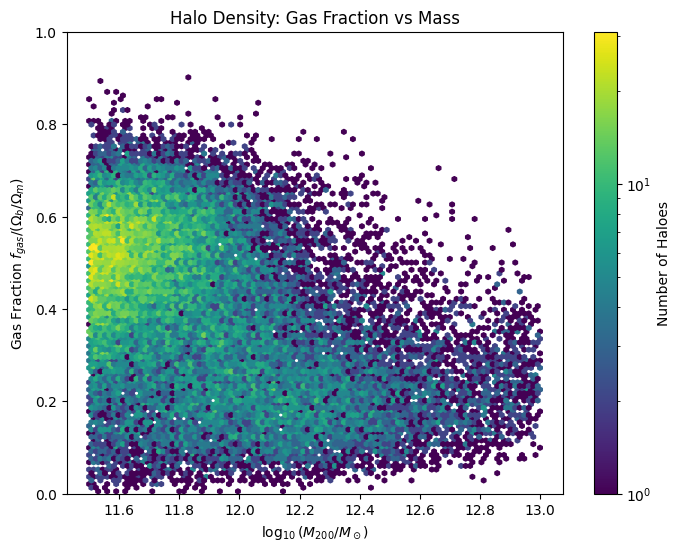

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))


hb = ax.hexbin(
    x=np.log10(df_results['mass']), 
    y= df_results['gas_frac'] /0.16, 
    gridsize=100,            
    cmap='viridis',         
    mincnt=1,    # disregard empty bins          
    bins='log'                      
)

# Add colourbar
cb = fig.colorbar(hb, ax=ax)
cb.set_label('Number of Haloes')  # Label reflects the count
plt.ylim(0,1)

ax.set_xlabel(r'$\log_{10}(M_{200} / M_\odot) $')
ax.set_ylabel('Gas Fraction $f_{gas} / (\Omega_{b} / \Omega_{m}$)')
ax.set_title('Halo Density: Gas Fraction vs Mass')

plt.show()

### 2.2 Load in anisotropy calculations from slurm job, combine with halo properties


Since I ran a few slurm jobs for this data due to an unrefined pipeline, I had to match the correct rows from different datasets

Luckily every slurm run matched computed properties with a halo index which made the merging of data simple

In [ ]:


# 1. Get a list of all result files
files = glob.glob('results/L200m6/gas_density_anisotropies_*.csv')

# 2. Read each file into a list and combine
df_final = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)


print(f"Total files found: {len(files)}")
print(f"Total halos in merged data: {len(df_final)}")

df_orig = pd.read_csv('results/halo_properties_L200m6.csv')

df_combined = pd.merge(df_orig, df_final, on='halo_index',how='left')

df_combined = df_combined[df_combined['mass_aniso'] < 4.0] ## Remove outliers

Total files found: 126
Total halos in merged data: 30128


### 2.3 Anisotropy Results

With the anisotropies calculated for all haloes within the snapshot, It was first thought to produce a binned gas fraction versus halo mass plot coloured by anisotropy to get a good idea with how anisotropy might behave. The plot was somewhat telling but the data needed further processing to constrain any relationships involved

The clustering of major axis dominated systems is of specific interest

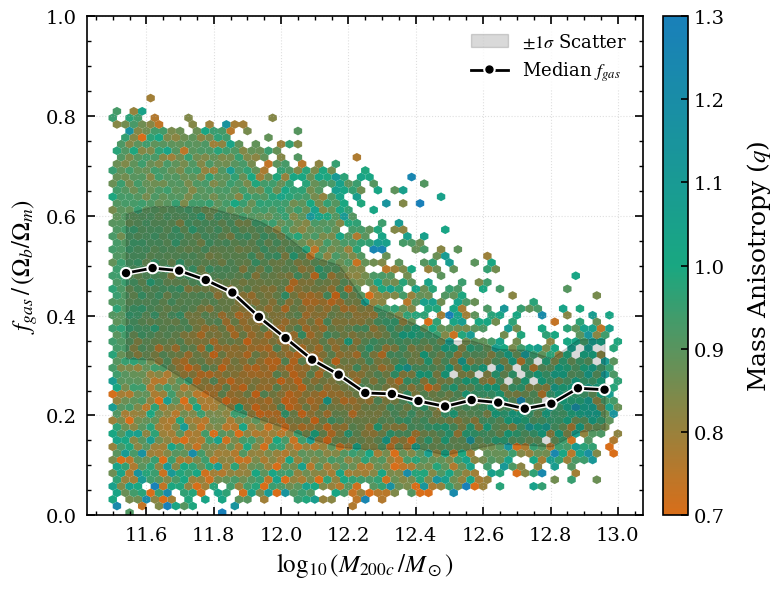

In [ ]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True

cb_red = "#D55E00"    
cb_green = "#009E73"  
cb_blue = "#0072B2"   
three_color_map = mcolors.LinearSegmentedColormap.from_list("rgb_safe", [cb_red, cb_green, cb_blue])

log_mass = np.log10(df_combined['mass']) # Logarith of all halo masses
gas_fraction = df_combined['gas_frac'] / 0.16 # Normalised baryon gas fractions
anisotropy = df_combined['mass_aniso'] # Anisotropy parameters for colouring


fig, ax = plt.subplots(figsize=(8, 6), dpi=100)


hb = ax.hexbin(
    log_mass, 
    gas_fraction, 
    C=anisotropy, 
    gridsize=60, 
    cmap=three_color_map,
    mincnt=2, # disregard empty or bins with only 1 halo
    reduce_C_function=np.median, # use median anisotropy for colour
    vmin=0.7,
    vmax=1.3,
    alpha=0.9, 
    edgecolors='none'
)

#CALCULATE AND PLOT THE MEDIAN LINE
bins = np.linspace(log_mass.min(), log_mass.max(), 20)

#Calculate the Median AND the 16th/84th percentiles
bin_medians, bin_edges, _ = binned_statistic(log_mass, gas_fraction, statistic='median', bins=bins)
bin_p16, _, _ = binned_statistic(log_mass, gas_fraction, statistic=lambda y: np.percentile(y, 16), bins=bins)
bin_p84, _, _ = binned_statistic(log_mass, gas_fraction, statistic=lambda y: np.percentile(y, 84), bins=bins)

bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Plot the shaded 1-sigma region
ax.fill_between(bin_centers, bin_p16, bin_p84, color='black', alpha=0.15, zorder=2, label=r'$\pm 1\sigma$ Scatter')

# Plot the median 
ax.plot(bin_centers, bin_medians, color='black', linewidth=2, linestyle='-', 
        marker='o', markersize=5, 
        path_effects=[pe.Stroke(linewidth=4, foreground='white'), pe.Normal()],
        label=r'Median $f_{gas}$', zorder=3)


ax.legend(loc='upper right', fontsize=13, frameon=True, framealpha=0.8, edgecolor='none')


ax.set_xlabel(r'$\log_{10}(M_{200c} \, /M_\odot)$', fontsize=18)
ax.set_ylabel(r'$f_{gas} \, / \, (\Omega_{b} / \Omega_{m})$', fontsize=18)

for spine in ax.spines.values():
    spine.set_linewidth(1.2)

ax.tick_params(axis='both', which='major', labelsize=14, length=6, width=1.2, pad=8)
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', length=3, width=1)

# 5. ADD COLORBAR
cbar = fig.colorbar(hb, ax=ax, pad=0.03)
cbar.set_label(r'Mass Anisotropy ($q$)', fontsize=18, labelpad=15)
cbar.ax.tick_params(labelsize=14, direction='in', length=5, width=1.2)
cbar.outline.set_linewidth(1.2) 

ax.grid(True, linestyle=':', alpha=0.4)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

### Median anisotropy as a function of binned mass for high and low mass systems

This plot was made to compare populations of the two extremes of gas fraction, and the plot was compelling

    (1) Population split up by Upper and Lower Quartiles of gas fraction at each mass bin

    (2) The median anisotropy for each population in each bin was calculated 

    (3) Due to such a large sample size, the standard error on each median was plotted. Bootstrapping later confirmed that this std error on the median was in fact accurate

Gas rich systems tend to be more isotropic over the full mass range, however the main divergence occurs at 10^{11.8}. All populations see a gradual restoration toward isotropy as mass increases however the gas poor population doesnt appear to make a full overall recovery and plateaus at around q = 0.9

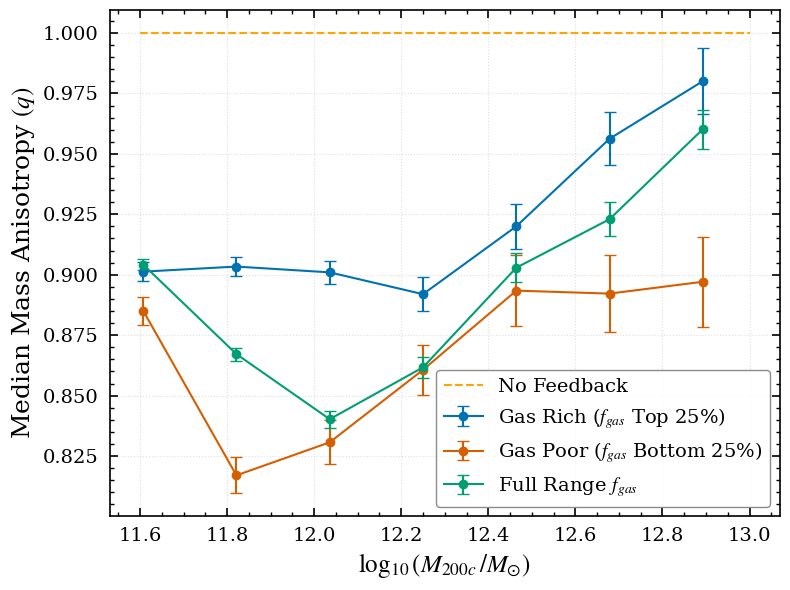

In [61]:


plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True


cb_red = "#D55E00"
cb_green = "#009E73"
cb_blue = "#0072B2"


bins = np.linspace(log_mass.min(), log_mass.max(), 8)
bin_centers = (bins[:-1] + bins[1:]) / 2


top_median, bottom_median, full_median = [], [], []
full_median_err, top_err, bottom_err = [], [], []

for i in range(len(bins)-1):
    mask = (log_mass >= bins[i]) & (log_mass < bins[i+1])
    bin_data = df_combined[mask]
    
    
    if len(bin_data) >= 20:
        q1 = bin_data['gas_frac'].quantile(0.25)
        q3 = bin_data['gas_frac'].quantile(0.75)
        
        top_q = bin_data[bin_data['gas_frac'] >= q3]
        bot_q = bin_data[bin_data['gas_frac'] <= q1]
        
        # Calculate Medians
        top_median.append(top_q['mass_aniso'].median())
        bottom_median.append(bot_q['mass_aniso'].median())
        full_median.append(bin_data['mass_aniso'].median())

        # Calculate Standard Error of the Median: 1.253 * (std / sqrt(N))
        full_median_err.append(1.253 * (bin_data['mass_aniso'].std() / np.sqrt(len(bin_data))))
        top_err.append(1.253 * (top_q['mass_aniso'].std() / np.sqrt(len(top_q))))
        bottom_err.append(1.253 * (bot_q['mass_aniso'].std() / np.sqrt(len(bot_q))))
    else:
        top_median.append(np.nan)
        bottom_median.append(np.nan)
        full_median.append(np.nan) # 
        top_err.append(np.nan)
        bottom_err.append(np.nan)
        full_median_err.append(np.nan)


fig, ax = plt.subplots(figsize=(8, 6), dpi=100)


ax.errorbar(bin_centers, top_median, yerr=top_err, fmt='o-', color=cb_blue, 
            capsize=4, elinewidth=1.5, label=r'Gas Rich ($f_{gas}$ Top 25%)')

ax.errorbar(bin_centers, bottom_median, yerr=bottom_err, fmt='o-', color=cb_red, 
            capsize=4, elinewidth=1.5, label=r'Gas Poor ($f_{gas}$ Bottom 25%)')

ax.errorbar(bin_centers, full_median, yerr=full_median_err, fmt='o-', color=cb_green, 
            capsize=4, elinewidth=1.5, label=r'Full Range $f_{gas}$')


ax.plot([11.6, 13.0], [1.0, 1.0], linestyle='--', color='orange', label='No Feedback')


ax.set_xlabel(r'$\log_{10}(M_{200c} \, / M_{\odot})$', fontsize=18)
ax.set_ylabel(r'Median Mass Anisotropy $(q)$', fontsize=18)


for spine in ax.spines.values():
    spine.set_linewidth(1.2)


ax.tick_params(axis='both', which='major', labelsize=14, length=6, width=1.2, pad=8)
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', length=3, width=1)


ax.legend(fontsize=14, framealpha=0.9, edgecolor='gray')
ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()